In [1]:
#installazione librerie necessarie
!pip install PyPDF2
!pip install requests
!pip install langchain
!pip install pdfminer.six
!pip install pyvis
!pip install networkx
!pip install PyQt5
!pip install crewai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 817.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 990.3/990.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.3/377.3 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.1/141.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.5/60.5 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.5/270.5 kB 16.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

#Codice base

Il file contiene tutti gli step del progetto. Lo step 1 prende i file in input e li salva in un file di testo. Nello step 2 si risponde a domande riguardanti i file caricati e le informazioni date allo step 1, si crea un nuovo file contenente le risposte. Lo step 3 genera il file per il grafo partendo dal contesto fornito negli step precedenti. Nello step 4 intervengono gli agenti per migliorare il file del grafo. Questo sembrerebbe non funzionare bene poichè il file su cui gli agenti lavorano è un file soggetto ad errori precedenti e in cui si perdono informazioni rispetto ai file inziali. Lo step 5 genera il grafo.

Le seguenti idee devono essere ancora costruite e implementate nel codice.


#Idea 1:
Gli agenti devono collaborare dalla creazione delle domande inerenti ai file forniti (dallo step 2).
Step 2: Un agente legge il file di testo e genera le domande.
Step 3: Una serie di agenti collabora al fine di creare il miglior set di triple e lo controlla.
Step 4: Generazione Grafo (Affidabile a degli agenti?)


#Idea 2:
Gli agenti entrano in azione dopo la generazione del grafo. Questi operano sul file di testo (formato dot) per migliorare le feature del grafo


#Idea 3:
Unione delle due idee precedenti. Gli agenti collaborano prima di generare il grafo e ne migliorano le feature successivamente

#Idea 4:
Miglioramento del grafo, vedi testo in fondo

Cose da rifare:

-Analisi testo per capitoli o cluster (svolto da agenti)

-Generazione triple, gli llm vengono chiamati troppe volte

-Eliminazione delle triple con intervento umano (agent+human)

In [ ]:
#step 1

import os
import PyPDF2
import requests

def write_context_to_file(responses, filename="/content/drive/MyDrive/Centur_AI_Interfacciato/context.txt"):
    with open(filename, "w", encoding='utf-8') as file:
        for question, response in responses.items():
            file.write(f"Q: {question}\nA: {response}\n\n")

def extract_pdf_from_url(url):
    response = requests.get(url)
    with open("temp.pdf", "wb") as f:
        f.write(response.content)
    return extract_text_from_pdf("temp.pdf")

def extract_pdf_from_path(path):
    return extract_text_from_pdf(path)

def extract_text_from_pdf(file_path):
    if not os.path.exists(file_path):
        return "File non trovato."

    with open(file_path, "rb") as file:
        reader = PyPDF2.PdfReader(file)
        text = []
        for page in reader.pages:
            text.append(page.extract_text())
    os.remove(file_path)  # Cleanup the temporary file
    return "".join(text)

class QuestionManager:
    def __init__(self, question_file):
        self.questions = self.load_questions(question_file)
        self.responses = {}

    def load_questions(self, filename):
        try:
            with open(filename, 'r', encoding='utf-8') as file:
                content = file.read()
                questions = [q.strip() for q in content.split('|') if q.strip()]
            return questions
        except FileNotFoundError:
            print("Il file non è stato trovato e quindi non è corretta la posizione che mi hai inserito.")
            return []
        except Exception as e:
            print(f"Si è verificato un errore: {e}")
            return []

    def ask_questions(self):
        for question in self.questions:
            print(question)
            response = input("Risposta: ")
            self.responses[question] = response

        return self.responses

def step1():
    question_file = "/content/drive/MyDrive/Centur_AI_Interfacciato/questions.txt"  # Assicurati che questo file esista nel percorso corretto
    qm = QuestionManager(question_file)
    responses = qm.ask_questions()

    # Processo le risposte per gestire i PDF
    for question, response in responses.items():
        if response.startswith("http://") or response.startswith("https://"):
            responses[question] = extract_pdf_from_url(response)
        elif os.path.exists(response):
            responses[question] = extract_pdf_from_path(response)

    # Scrive le domande e le risposte nel file context.txt
    write_context_to_file(responses)

    return responses

step1()

Hello! I'm CentureAI. To start, could you please tell me your main area of interest or the theme you wish to explore with the knowledge graph?
Risposta: The rules of Lupus In Tabula
Could you send me the link to a PDF document that contains the information you want to analyze?
Risposta: no
If you have a document on your computer you'd like to use, please provide the path to the file.
Risposta: /content/drive/MyDrive/Centur_AI_Interfacciato/LupusInTabulaENGRules.pdf
Are there specific concepts or key terms you expect to find in the document? This will help me identify them more effectively.
Risposta: I expect to find every character, the phases of the game and the actions beetwen players and characters
Do you want me to focus on any specific section of the document, or should I analyze the entire document?
Risposta: Analyze all the document, especially the part where every character is explained 
How detailed would you like the analysis to be? Do you want it to include secondary informa

{"Hello! I'm CentureAI. To start, could you please tell me your main area of interest or the theme you wish to explore with the knowledge graph?": 'The rules of Lupus In Tabula',
 'Could you send me the link to a PDF document that contains the information you want to analyze?': 'no',
 "If you have a document on your computer you'd like to use, please provide the path to the file.": '®\nLupus in Tabula®\nAuthor: Domenico Di Giorgio\nDevelopment: Andrés J. Voicu, Mucca Games Team\nGraphic and Illustrations: Gianpaolo Derossi\nRules editing: Roberto Corbelli, Andrés J. Voicu, William Niebling\nFor questions, comments and suggestions: www.dvgiochi.com - info@dvgiochi.com\nFOLLOW US:  Copyright © MMX\ndaVinci Editrice S.r.l.\nVia S. Penna, 24\n06132 Perugia\nAll rights reserved.\nA thrilling game for 8 – 24 players, aged 8 and up\nWerewolves haunt the secluded village known as Tabula: every night some villagers turn into \nwerewolves and slaughter an innocent victim to satisfy their hunger.

In [ ]:
#step 2

from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_community.document_loaders import WebBaseLoader
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pdfminer.high_level import extract_text
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain.chains.combine_documents import create_stuff_documents_chain
import json

def step2():
    # Inizializza il parser di output
    output_parser = StrOutputParser()

    # Imposta l'API per GPT-4
    openai_api_key = "tuo_openai_api_key"  # Sostituisci con la tua chiave API
    llm = ChatOpenAI(openai_api_key=openai_api_key, model='gpt-3.5-turbo')

    # Definisci il template della risposta
    template = "You ask necessary questions that would serve your agent to extract deterministic knowledge from the given context."

    # Definisci l'input
    input_prompt = "Ask n-questions that will allow you to create a knowledge graph in triples. IT MUST BE COMPLETE"

    # Carica il contesto da un file
    context_file_path = '/content/drive/MyDrive/Centur_AI_Interfacciato/context.txt'  # Assicurati che questo percorso sia corretto
    with open(context_file_path, 'r') as file:
        text = file.read()

    embeddings = OpenAIEmbeddings(openai_api_key=openai_api_key)
    context_documents = [Document(page_content=text)]

    # Crea il prompt
    prompt = ChatPromptTemplate.from_template(template +"""Do this based also on the provided context:
    <context>
    {context}
    </context>
    Question: {input}""")

    # Crea la catena di documenti
    document_chain = create_stuff_documents_chain(llm, prompt)

    # Invoca la catena per ottenere i dati
    databang = document_chain.invoke({
        "system": template,
        "input": input_prompt,
        "context": context_documents
    })
 # Dividi le domande per righe
    questions = databang.split("\n")

    # Dizionario per memorizzare le risposte
    responses = {}

    # Chiedi le domande all'utente
    for question in questions:
        if question.strip():  # Assicurati che la domanda non sia vuota
            print(question)
            response = input("Risposta: ")  # Raccogli la risposta
            responses[question] = response  # Memorizza la risposta

    # Scrivi la combinazione di domande e risposte in context2.txt
    with open("/content/drive/MyDrive/Centur_AI_Interfacciato/context2.txt", "w", encoding="utf-8") as output_file:
        for question, response in responses.items():
            output_file.write(f"Q: {question}\nA: {response}\n\n")

step2()

1. Can you provide a list of all the characters included in the game Lupus In Tabula?
Risposta: villagers, seer, werewolves, bodyguard, owl-man,  medium, possessed,  werehamester, freemasonsand mythomaniac
2. What are the special abilities of the Medium character in the game?
Risposta: he is a Human who can communicate with the spirits. At the  beginning of each night (starting from the second one, see the icon), the  Moderator calls his phase, and shows him thumbs-up, if the last player lynched  was a Werewolf, thumbs-down if not.
3. How does the Possessed character interact with the Werewolves in the game?
Risposta: he is a Human, but he sides with the Werewolves... without  knowing who they are! Therefore he wins if the Werewolves win.
4. What is the role of the Bodyguard character during the night phase of the game?
Risposta: : he is a Human who protects a player of his choice each  night. At night (starting with the second one), before the Werewolves’  phase, the Moderator calls t

In [ ]:
#step 3

import tkinter as tk
import networkx as nx
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import OpenAIEmbeddings
import matplotlib.pyplot as plt
from langchain_openai import ChatOpenAI
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain.chains.combine_documents import create_stuff_documents_chain
import os
import sys
import PyQt5
from PyQt5.QtWidgets import QApplication, QWidget, QVBoxLayout, QLabel, QPushButton, QMessageBox, QLineEdit


def first_triple_generation(context):
    # Inizializza il parser di output
    output_parser =StrOutputParser()

    # Imposta l'API per GPT-4
    openai_api_key ="tuo_openai_api_key"  # Sostituisci con la tua chiave API
    llm = ChatOpenAI(openai_api_key=openai_api_key,model="gpt-3.5-turbo")

    # Definisci il template della risposta
    template="The structure of the output should be exactly:  Entity1 | Relation | Entity2"

    # Definisci l'input
    input_prompt ="Based on the context create a unique triple of the form: Entity1 | Relation | Entity2"

    #Define Context
    embeddings =OpenAIEmbeddings(openai_api_key="tuo_openai_api_key" )
    context_documents = [Document(page_content=context)]
    # Crea il prompt
    prompt = ChatPromptTemplate.from_template(template + """The information that you need to create the first triple of the graph is:
    <context>
    {context}
    </context>
    Question: {input}""")
    # Crea la catena di documenti
    document_chain = create_stuff_documents_chain(llm, prompt)
    # Invoca il LLM per generare la tripla
    suggestion=document_chain.invoke({
        "system": template,
        "input": input_prompt,
        "context": context_documents
    })

    # Nome del file
    file_name = "/content/drive/MyDrive/Centur_AI_Interfacciato/graph.txt"

    # Usando il blocco 'with', il file verrà chiuso automaticamente dopo la scrittura
    with open(file_name, 'w') as file:  # 'w' per scrivere (sovrascrittura)
        file.write(suggestion + '\n')  # Scrive la variabile nel file
    return suggestion

################################################################################################################################

def n_triple_generation(context):
    # Nome del file da leggere
    file_name = "/content/drive/MyDrive/Centur_AI_Interfacciato/graph.txt"

    # Variabile per salvare il contenuto
    past_triple = ""

    # Usa il blocco 'with' per assicurare la corretta chiusura del file
    with open(file_name, 'r') as file:
        past_triple = file.read()  # Legge l'intero contenuto del file

    # Inizializza il parser di output
    output_parser =StrOutputParser()

    # Imposta l'API per GPT-4
    openai_api_key ="tuo_openai_api_key"  # Sostituisci con la tua chiave API
    llm = ChatOpenAI(openai_api_key=openai_api_key,model="gpt-3.5-turbo")

    # Definisci il template della risposta
    template="The structure of the output should be exactly:  Entity1 | Relation | Entity2"

    # Definisci l'input
    input_prompt ="I'm creating a graph (DAG) composed by a set of triple of the form  Entity1 | Relation | Entity2 : , What I have created so far is:" +past_triple+ ". Now you must create a new triple to add and it should contains new information not already contained in the graph."

    #Define Context
    embeddings =OpenAIEmbeddings(openai_api_key="tuo_openai_api_key ")
    context_documents = [Document(page_content=context)]
    # Crea il prompt
    prompt = ChatPromptTemplate.from_template(template + """The information that you need to create the first triple of the graph are:
    <context>
    {context}
    </context>
    Question: {input}""")
    # Crea la catena di documenti
    document_chain = create_stuff_documents_chain(llm, prompt)
    # Invoca il LLM per generare la tripla
    suggestion=document_chain.invoke({
        "system": template,
        "input": input_prompt,
        "context": context_documents
    })

    with open(file_name, 'a') as file:
        file.write(suggestion+ '\n')

    return suggestion




################## MAIN CODE ##################################################################
# Carica il contesto da context1 e context2
context1_path = 'context.txt'
context2_path = 'context2.txt'

with open(context1_path, 'r', encoding='utf-8') as file:
    context1 = file.read()

with open(context2_path, 'r', encoding='utf-8') as file:
    context2 = file.read()

combined_context = context1 + "\n" + context2  # Unione dei due contesti

#CREAZIONE GRAFO
z = first_triple_generation(combined_context)

#CODICE PER GESTIRE TRIPLA E METTERE QUELLE ACCETTATE NEL GRAFO
for x in range(100):
    z = n_triple_generation(combined_context)
    print(z)
    tripla, ok = z, True
    if ok and tripla:
        entity1, relation, entity2 = tripla.split(" | ")




###########CODICE PER OTTIMIZZAZIONE CON APPROCCIO AD AGENTI ###############



##########CREAZIONE GRAFO################

In [ ]:
#step 3 rifatto ad agenti

from crewai import Agent, Task, Crew, Process
from langchain_openai import ChatOpenAI
import os

os.environ['OPENAI_MODEL_NAME']='gpt-3.5-turbo'
os.environ['OPENAI_API_KEY']='tuo_openai_api_key'  # Sostituisci con la tua chiave API

llm=ChatOpenAI(temperature=0)

with open('/content/drive/MyDrive/Centur_AI_Interfacciato/context.txt', 'r') as f:
  context1 = f.read()

with open('/content/drive/MyDrive/Centur_AI_Interfacciato/context2.txt', 'r') as f:
    context2 = f.read()

context = "<files>\n" + context1 + "<\ files>\n\n" + "<questions>\n" + context2

def triples_generator(context):
    cluster_analyzer=Agent(
        role='sections seeker',
        backstory='you are an expert in summarizing',
        goal='create chapters from the files in the given context and create a quick summary',
        llm=llm,
        allow_delegation=False,
        Verbose=True)

    cluster_task=Task(
        agent=cluster_analyzer,
        description=f'''analyze the given context and split it out in chapters, every chapter must have a quick summary at the beginning, be careful to the final questions they are really important to you, follow them and not include them in the final output.
        <context>
        {context}''',
        expected_output='a list of files, every file must contain only one chapter. the files must contain title, summary and the content of the chapter')

    triples_creator=Agent(
        role='computer scientist',
        backstory='you have a lot of experience in knowledge graph',
        goal='create the best triple possible for a knowledge graph',
        llm=llm,
        Human_input=True,
        allow_delegation=False,
        Verbose=True)

    creator_task=Task(
        agent=triples_creator,
        description='create a set of triples for a knowledge graph from the given list of chapters, every chapter create a cluster in the graph',
        expected_output='a file containing a set of triples for the generation of a knowledge graph, a triple per line and every triple must be in the form: entity1|relation|entity2')

    checker=Agent(
        role='quality checker',
        backstory='you prefer precision information over general ones',
        goal='check for the exhaustiveness of the triples',
        llm=llm,
        allow_delegation=False,
        Verbose=True
    )

    checker_task=Task(
        agent=checker,
        description='compare the file with the triples against the context, if you think improvement is possible signal it',
        expected_output='a file with corrections about the created file of triples'
    )

    crew=Crew(
        agents=[cluster_analyzer, triples_creator,checker, triples_creator],
        tasks=[cluster_task, creator_task,checker_task,creator_task],
        process=Process.sequential,
        Verbose=True)

    result=crew.kickoff()
    return result

file=triples_generator(context)
print(file)

# with open('/content/drive/MyDrive/Centur_AI_Interfacciato/graph.txt', 'w') as f:
#    f.write(file)


Characters in Lupus In Tabula|includes|villagers
Characters in Lupus In Tabula|includes|seer
Characters in Lupus In Tabula|includes|werewolves
Characters in Lupus In Tabula|includes|bodyguard
Characters in Lupus In Tabula|includes|owl-man
Characters in Lupus In Tabula|includes|medium
Characters in Lupus In Tabula|includes|possessed
Characters in Lupus In Tabula|includes|werehamster
Characters in Lupus In Tabula|includes|freemasons
Characters in Lupus In Tabula|includes|mythomaniac
Special Abilities of Characters|explains|medium's ability to communicate with spirits
Special Abilities of Characters|explains|possessed character siding with werewolves
Special Abilities of Characters|explains|bodyguard's role in protecting a player each night
Game Variants|explores|game variant "The Phantom Menace"
Game Variants|introduces|new gameplay elements using sword and shield symbols on ghost cards
Game Variants|impacts|voting and suspecting process in the game
Strategies for Success|provides|key st

In [ ]:
#step 3 rifatto con le chain

import os
from langchain_openai import ChatOpenAI
from langchain.chains import LLMChain, SequentialChain
from langchain.prompts import ChatPromptTemplate

os.environ['OPENAI_MODEL_NAME']='gpt-3.5-turbo'
os.environ['OPENAI_API_KEY']='tuo_openai_api_key'  # Sostituisci con la tua chiave API

with open('/content/drive/MyDrive/Centur_AI_Interfacciato/context.txt', 'r') as f:
  context1 = f.read()

with open('/content/drive/MyDrive/Centur_AI_Interfacciato/context2.txt', 'r') as f:
    context2 = f.read()

context = "<files>\n" + context1 + "<\ files>\n\n" + "<questions>\n" + context2

llm=ChatOpenAI(temperature=0)

prompt1=ChatPromptTemplate.from_template(
    '''analyze the given context and split it out in chapters,
    every chapter must have a quick summary at the beginning, be careful to the final questions they are really important to you,
    follow them and not include them in the final output.
    The output includes the chapters with their summaries
    <context>
    {context}''')

chain1=LLMChain(llm=llm, prompt=prompt1, output_key='chapters')

prompt2=ChatPromptTemplate.from_template(
    '''create a file of triples for a knowledge graph from the given list of chapters, every chapter create a cluster in the graph. A triple must be in the form entity1|relation|entity2
    BE SPECIFIC!!!
    <context>
    {context}
    </context>
    <chapters>
    {chapters}''')

chain2=LLMChain(llm=llm, prompt=prompt2, output_key='triples')

chain=SequentialChain(chains=[chain1, chain2], input_variables=['context'], output_variables=['triples'], verbose=True)

result=chain.invoke(context)
triples=result['triples'].strip("<knowledge_graph_triples>\n").strip("\n</knowledge_graph_triples>")

with open('/content/drive/MyDrive/Centur_AI_Interfacciato/graph.txt', 'w') as f:
   f.write(triples)



> Entering new SequentialChain chain...

> Finished chain.


In [ ]:
#step 4

from langchain.prompts import ChatPromptTemplate
from langchain.chains.combine_documents import create_stuff_documents_chain
import crewai
from crewai import Agent, Task, Process
import os
from langchain_openai import ChatOpenAI


#step ad agenti per migliorare le triple

os.environ['OPENAI_MODEL_NAME']='gpt-3.5-turbo'
os.environ['OPENAI_API_KEY']='tuo_openai_api_key'  # Sostituisci con la tua chiave API
llm=ChatOpenAI()

with open('/content/drive/MyDrive/Centur_AI_Interfacciato/graph.txt', 'r') as f:
  context=f.read()




In [13]:
#step 5

from IPython.display import HTML, display
import networkx as nx
from pyvis.network import Network


# Funzione per leggere il file e costruire il grafo
def create_knowledge_graph(file_path):
    G = nx.DiGraph()
    with open(file_path, 'r') as f:
        content = f.read().strip()
        relations = content.split('\n')
        for relation in relations:
            if relation:
                entity1, relationship, entity2 = relation.split('|')
                entity1 = entity1.strip()
                relationship = relationship.strip()
                entity2 = entity2.strip()
                G.add_node(entity1)
                G.add_node(entity2)
                G.add_edge(entity1, entity2, label=relationship)
    return G

# Funzione per visualizzare il grafo interattivo
def draw_knowledge_graph(G):

    net = Network(notebook=True, cdn_resources='in_line')
    for node in G.nodes:
        net.add_node(node, label=node, title=node, shape='ellipse', color='skyblue')

    for edge in G.edges(data=True):
        net.add_edge(edge[0], edge[1], label=edge[2]['label'], title=edge[2]['label'])

    #net.show_buttons(filter_=['physics'])
    html = net.generate_html()
    with open("/content/drive/MyDrive/Centur_AI_Interfacciato/example.html", mode='w', encoding='utf-8') as fp:
            fp.write(html)
    display(HTML(html))

# Percorso al file graph.txt
file_path = '/content/drive/MyDrive/Centur_AI_Interfacciato/graph.txt'

# Crea il grafo della conoscenza
G = create_knowledge_graph(file_path)

# Visualizza il grafo interattivo
draw_knowledge_graph(G)

In [ ]:
#idea 2 (attualmente vengono generati troppi token, quasi 300k)

from crewai import Agent, Task, Crew, Process
from langchain_openai import ChatOpenAI
import os


os.environ['OPENAI_MODEL_NAME']='gpt-3.5-turbo'
os.environ['OPENAI_API_KEY']='tuo_openai_api_key'  # Sostituisci con la tua chiave API

with open("/content/drive/MyDrive/Centur_AI_Interfacciato/example.html", 'r') as f:
  graph = f.read()

llm=ChatOpenAI(temperature=0.3)

# text_analyzer = Agent(
#     role="Text Analyzer",
#     goal='Analyze the given text and understand its goals, main points ad topics',
#     backstory='you are an expert with a specific preparation in html2text file',
#     llm=llm,
#     allow_delegation=False)

# text_analyzer_task=Task(
#     description=f'''Analyze the given graph to undestrand its goals, main points and topics
#     <graph>
#     {graph}
#     </graph>
#     ''',
#     expected_output='a file explaining what you undesrstood of the graph',
#     agent=text_analyzer)

# graph_quality=Agent(
#     role="Graph Quality Checker",
#     goal='Improve the given graph',
#     backstory='You are an expert graphic with a specific backgrounfìd in graph building',
#     llm=llm,
#     allow_delegation=False)

# graph_quality_task=Task(
#     description=f'''Analyze the given graph and try to improve his readability maintaining the goals, main points and topics given in the file
#     <graph>
#     {graph}
#     <\graph>
#     <file>
#     {file}''',
#     expected_output='the raph in an html file',
#     agent=graph_quality)

# crew= Crew(
#     agents=[text_analyzer, graph_quality],
#     tasks=[text_analyzer_task, graph_quality_task],
#     process=Process.sequential)

# result=crew.kickoff()

# with open('/content/drive/MyDrive/Centur_AI_Interfacciato/result.html', 'w') as f:
#   f.write(result)

How to improve the graph

# Contextual Information:

Tooltips: Add tooltips to nodes and edges to provide additional information when hovered over.

Legends: Include a legend to explain the meaning of node and edge colors, sizes, and other visual attributes.

# Simplification:

Filter Nodes and Edges: If the graph is too dense, consider filtering out less important nodes or edges based on certain criteria.

Clustering: Group highly interconnected nodes into clusters and represent them as single nodes to reduce visual complexity.
si potrebbe creare un supergrafo riguardante il file e le sue componenti ( metadati, etc), cliccando sui nodi si apre un sottografo riguardamte quel nodo. Sostanzialmente i nodi del supergrafo sono cluster di informazioni

In [ ]:
#step 5 con modifiche

from IPython.display import HTML, display
import networkx as nx
from pyvis.network import Network

# Funzione per leggere il file e costruire il grafo
def create_knowledge_graph(file_path):
    G = nx.DiGraph()
    with open(file_path, 'r') as f:
        content = f.read().strip()
        relations = content.split('\n')
        for relation in relations:
            if relation:
                entity1, relationship, entity2 = relation.split('|')
                entity1 = entity1.strip()
                relationship = relationship.strip()
                entity2 = entity2.strip()
                G.add_node(entity1)
                G.add_node(entity2)
                G.add_edge(entity1, entity2, label=relationship)
    return G

# Funzione per visualizzare il grafo interattivo
def draw_knowledge_graph(G):

    net = Network(notebook=True, cdn_resources='in_line')
    for node in G.nodes:
        net.add_node(node, label=node, title=node, shape='ellipse', color='skyblue')

    for edge in G.edges(data=True):
        net.add_edge(edge[0], edge[1], label=edge[2]['label'], title=edge[2]['label'])

    #net.show_buttons(filter_=['physics'])
    net.set_options("""
         const options = {
           "physics": {
                "hierarchicalRepulsion": {
                    "centralGravity": 0,
                    "springLength": 500,
                    "springConstant": 0,
                    "nodeDistance": 440,
                    "damping": 0.16,
                    "avoidOverlap": 0.9
                },
            "minVelocity": 0.75,
            "solver": "hierarchicalRepulsion"
            }
        }
    """)
    html = net.generate_html()
    with open("/content/drive/MyDrive/Centur_AI_Interfacciato/example.html", mode='w', encoding='utf-8') as fp:
            fp.write(html)
    display(HTML(html))

#creazione cluster
def cluster_creation(file):
    with open(file, 'r') as f:
      content = f.read().strip()
      relations = content.split('\n')
      for relation in relations:
        if relation:
          entity1, relationship, entity2 = relation.split('|')
    return

# Percorso al file graph.txt
file_path = '/content/drive/MyDrive/Centur_AI_Interfacciato/graph.txt'

# Crea il grafo della conoscenza
G = create_knowledge_graph(file_path)

# Visualizza il grafo interattivo
draw_knowledge_graph(G)

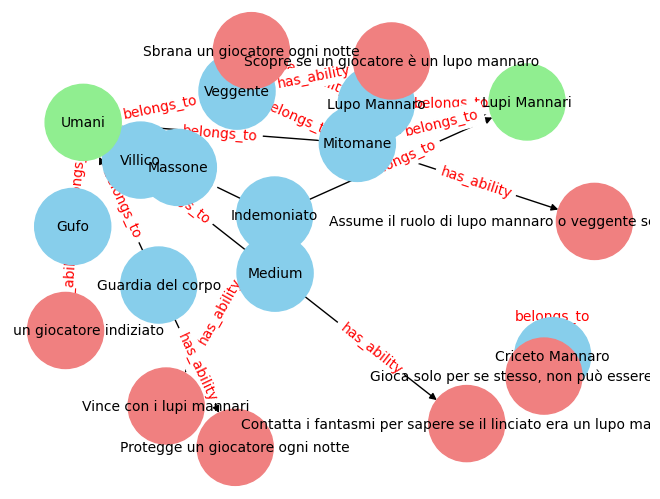

In [ ]:
#grafo personaggi chatgpt

import networkx as nx
import matplotlib.pyplot as plt

# Creazione del grafo
G = nx.DiGraph()

# Aggiunta delle entità (nodi)
characters = [
    "Lupo Mannaro", "Veggente", "Villico", "Medium", "Indemoniato",
    "Guardia del corpo", "Gufo", "Massone", "Criceto Mannaro", "Mitomane"
]
for char in characters:
    G.add_node(char, type="character")

# Aggiunta delle fazioni
factions = ["Lupi Mannari", "Umani"]
for faction in factions:
    G.add_node(faction, type="faction")

# Aggiunta delle relazioni (archi)
relations = [
    ("Lupo Mannaro", "Lupi Mannari"), ("Veggente", "Umani"), ("Villico", "Umani"),
    ("Medium", "Umani"), ("Indemoniato", "Umani"), ("Indemoniato", "Lupi Mannari"),
    ("Guardia del corpo", "Umani"), ("Gufo", "Umani"), ("Massone", "Umani"),
    ("Criceto Mannaro", "Criceto Mannaro"), ("Mitomane", "Umani"), ("Mitomane", "Lupi Mannari"),
    ("Mitomane", "Veggente")
]
for rel in relations:
    G.add_edge(rel[0], rel[1], type="belongs_to")

# Aggiunta delle abilità
abilities = {
    "Lupo Mannaro": "Sbrana un giocatore ogni notte",
    "Veggente": "Scopre se un giocatore è un lupo mannaro",
    "Medium": "Contatta i fantasmi per sapere se il linciato era un lupo mannaro",
    "Indemoniato": "Vince con i lupi mannari",
    "Guardia del corpo": "Protegge un giocatore ogni notte",
    "Gufo": "Indica un giocatore indiziato",
    "Criceto Mannaro": "Gioca solo per se stesso, non può essere sbranato",
    "Mitomane": "Assume il ruolo di lupo mannaro o veggente se sceglie il personaggio giusto"
}

for char, ability in abilities.items():
    G.add_node(ability, type="ability")
    G.add_edge(char, ability, type="has_ability")

# Disegno del grafo
pos = nx.spring_layout(G)
node_labels = {node: node for node in G.nodes()}

# Colorare nodi per tipo
colors = []
for node in G.nodes(data=True):
    if node[1]['type'] == "character":
        colors.append('skyblue')
    elif node[1]['type'] == "faction":
        colors.append('lightgreen')
    else:
        colors.append('lightcoral')

nx.draw(G, pos, with_labels=True, node_color=colors, node_size=3000, font_size=10)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'type'), font_color='red')

plt.savefig('/content/drive/MyDrive/Centur_AI_Interfacciato/gptGraph.jpeg')
